
══════════════════════════════════════════════════════════════════════════
  REPORT — BARICENTRI DI WASSERSTEIN SU 4 ETF
══════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────────
  DATI
──────────────────────────────────────────────────────────────────────────
    ETF analizzati : Asia-Pacifico, Emergenti, Europa, Nord America
    Osservazioni   : 2733 giorni  (2014-06-03 → 2024-12-30)

──────────────────────────────────────────────────────────────────────────
  GRIGLIA 1
──────────────────────────────────────────────────────────────────────────
    pesi α che minimizzano / massimizzano l'entropia (differenziale, bin-free):

                      Asia-Pac.  Emergenti     Europa   Nord Am.          H
    ───────────────────────────────────────────────────────────────────────
    uniforme             +25.0%     +25.0%     +25.0%     +25.0%    -3.0745
    min entropia          +0.0%      +0.0%   

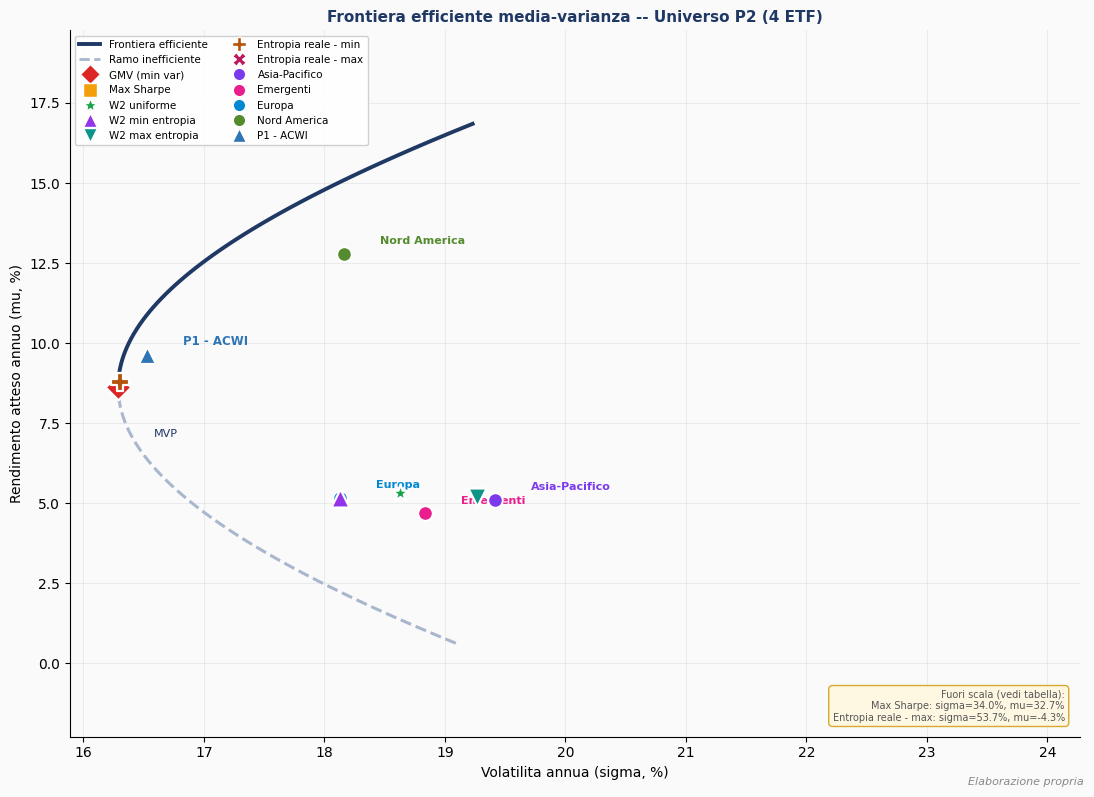

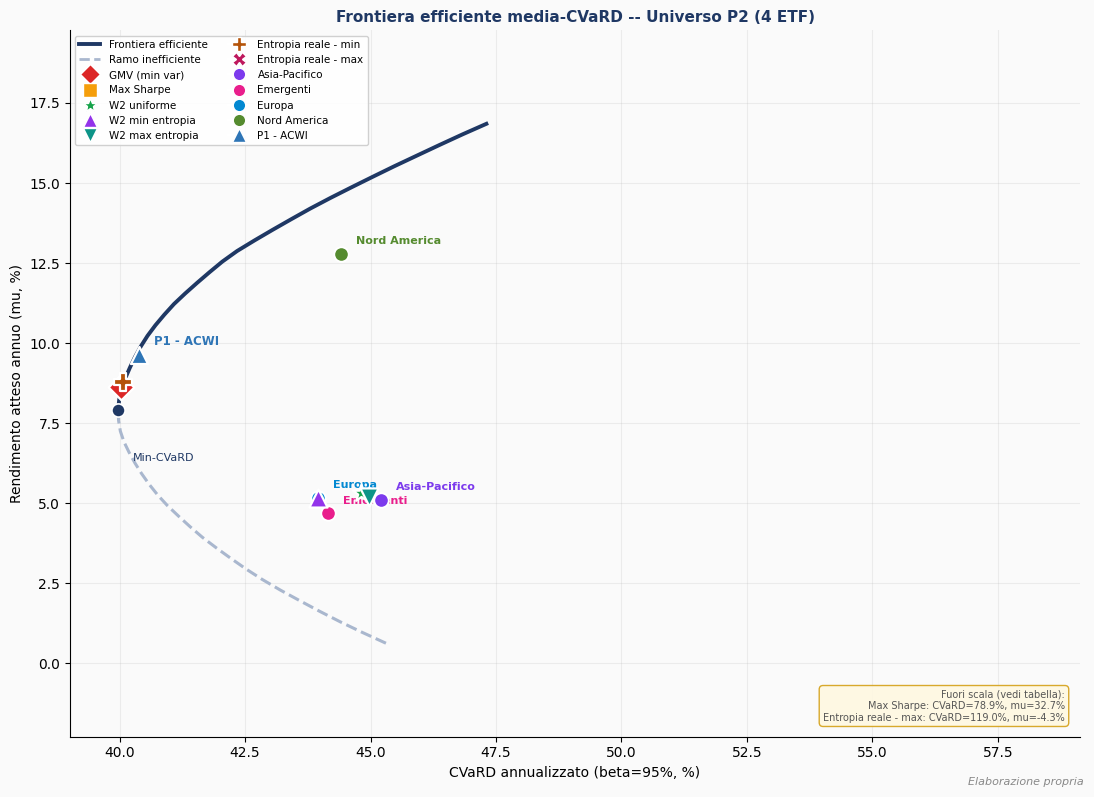

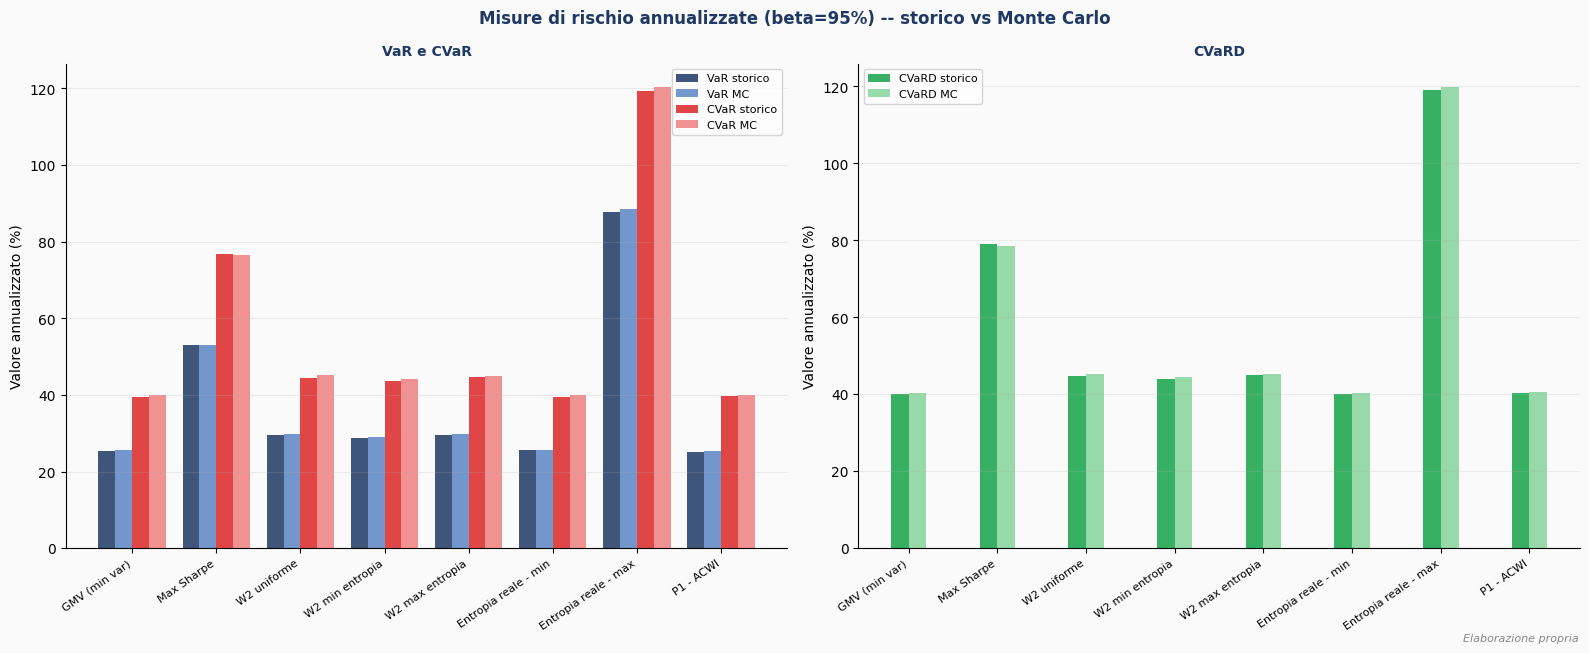

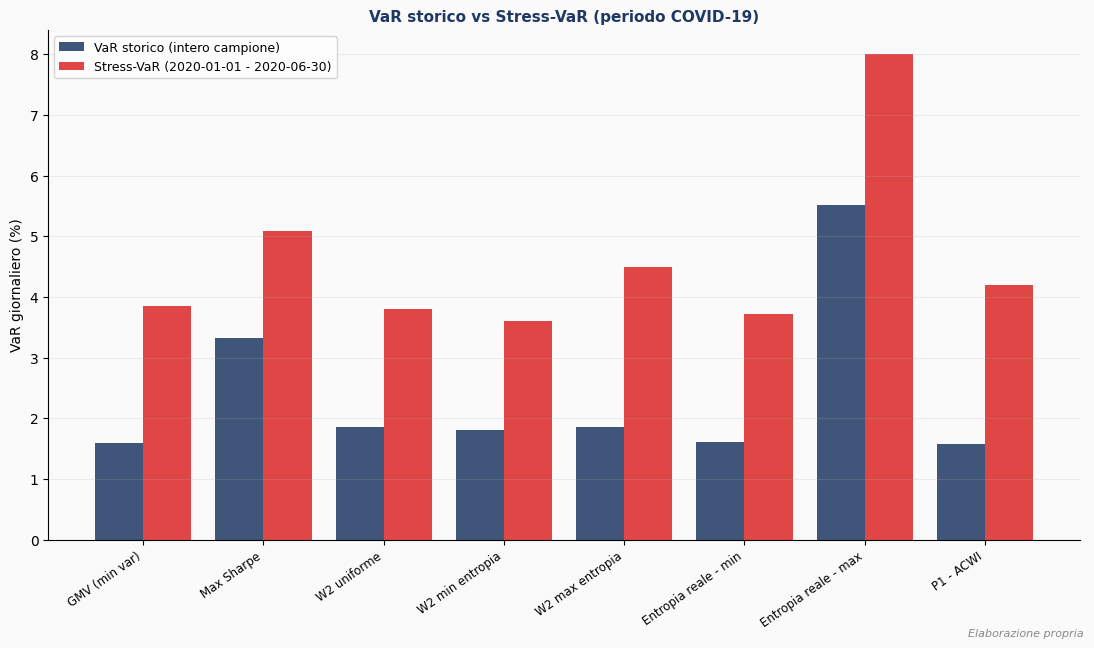

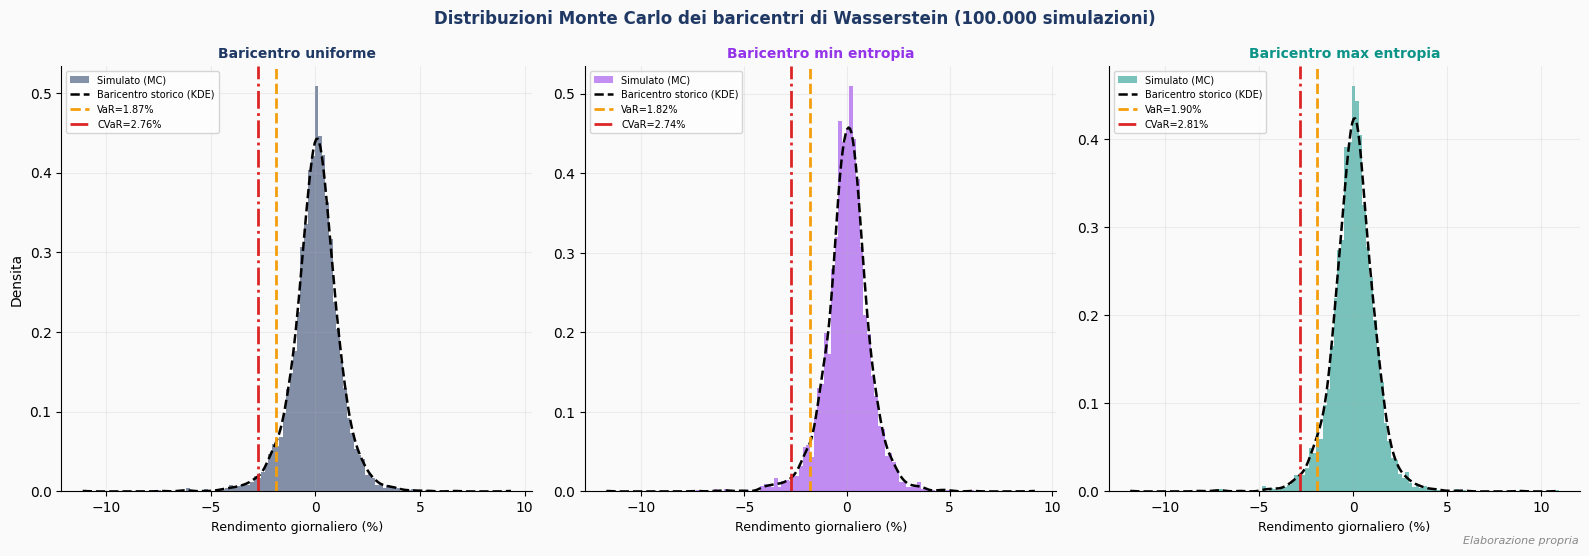

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# scarica_dati.py — Download dati ETF (4 portafogli regionali + benchmark ACWI)
# Analisi Baricentri di Wasserstein su ETF — Tesi di Laurea
# ══════════════════════════════════════════════════════════════════════════════
# Scarica i prezzi giornalieri da Yahoo Finance, li converte in USD (valuta base)
# e calcola i rendimenti giornalieri semplici.
#
# Uso come script:   python scarica_dati.py
# Uso come modulo:    from scarica_dati import scarica_dati
#                     raw, returns = scarica_dati()
# ══════════════════════════════════════════════════════════════════════════════
import sys, io
if sys.stdout.encoding and sys.stdout.encoding.lower().startswith('cp'):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')

import yfinance as yf
import os
import numpy as np
import pandas as pd
from scipy.stats import differential_entropy, skew, kurtosis
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")


# ── Configurazione ────────────────────────────────────────────────────────────
P1_TICKER   = "ACWI"                                  # benchmark globale (USD)
P2_TICKERS  = ["CPXJ.AS", "EIMI.L", "IMEU.AS", "INAA.AS"]  # 4 ETF regionali
TICKERS     = [P1_TICKER] + P2_TICKERS

P2_LABELS   = {"CPXJ.AS": "Asia-Pacifico", "EIMI.L": "Emergenti",
               "IMEU.AS": "Europa",        "INAA.AS": "Nord America"}
P2_BREVI    = {"CPXJ.AS": "Asia-Pac.", "EIMI.L": "Emergenti",
               "IMEU.AS": "Europa",    "INAA.AS": "Nord Am."}

START       = "2014-06-01"
END         = "2024-12-31"

RF_ANNUAL   = 0.015              # tasso risk-free annuo (per lo Sharpe)
RF_DAILY    = RF_ANNUAL / 252
GIORNI_ANNO = 252               # giorni di borsa per l'annualizzazione

# Gli ETF .AS sono quotati in EUR e vanno convertiti in USD (valuta base).
# ACWI (NYSE) e EIMI.L (LSE, classe USD) sono già in dollari.
EUR_TICKERS = ["CPXJ.AS", "IMEU.AS", "INAA.AS"]


CACHE_PREZZI = "prezzi_usd.csv"


def scarica_dati(tickers=TICKERS, start=START, end=END,
                 eur_tickers=EUR_TICKERS, salva_csv=False, verbose=True,
                 usa_cache=True, forza_download=False, cache=CACHE_PREZZI):
    """Scarica i prezzi ETF, li converte in USD e calcola i rendimenti giornalieri.

    Parametri
    ---------
    tickers : list[str]   ticker da scaricare (default: ACWI + 4 ETF regionali)
    start, end : str      intervallo date (YYYY-MM-DD)
    eur_tickers : list[str]   ticker quotati in EUR da convertire in USD
    salva_csv : bool      se True salva 'prezzi_usd.csv' e 'rendimenti.csv'
    verbose : bool        se True stampa un riepilogo a schermo
    usa_cache : bool      se True e il file cache esiste, lo rilegge invece di scaricare
    forza_download : bool se True ignora la cache e riscarica (reset cache)
    cache : str           file dei prezzi USD usato come cache

    Ritorna
    -------
    raw : pd.DataFrame      prezzi di chiusura in USD (colonne = ticker)
    returns : pd.DataFrame  rendimenti giornalieri semplici in USD
    """
    # ── Cache: rileggi i prezzi USD già scaricati ────────────────────────────
    if usa_cache and not forza_download and os.path.exists(cache):
        raw = pd.read_csv(cache, index_col=0, parse_dates=True)
        returns = raw.pct_change().dropna()
        if verbose:
            print(f"✓ Prezzi letti da cache '{cache}'  "
                  f"({len(returns)} giorni, {list(raw.columns)})")
        if salva_csv:
            returns.to_csv("rendimenti.csv")
        return raw, returns

    if verbose:
        print("=" * 65)
        print("DOWNLOAD ETF e RENDIMENTI GIORNALIERI (valuta base: USD)")
        print("=" * 65)

    # ── Download prezzi di chiusura (aggiustati) ─────────────────────────────
    raw = yf.download(tickers, start=start, end=end,
                      auto_adjust=True, progress=verbose)["Close"]
    raw.dropna(how="all", inplace=True)
    raw.dropna(axis=1, how="all", inplace=True)
    raw.ffill(inplace=True)
    raw.dropna(inplace=True)

    # ── Conversione in USD: prezzo_USD = prezzo_EUR × EURUSD ──────────────────
    if eur_tickers:
        if verbose:
            print("\nDownload tasso di cambio EUR/USD...")
        fx = yf.download("EURUSD=X", start=start, end=end,
                         auto_adjust=True, progress=False)["Close"]
        fx = fx.reindex(raw.index).ffill().bfill()
        if isinstance(fx, pd.DataFrame):
            fx = fx.squeeze()
        for t in eur_tickers:
            if t in raw.columns:
                raw[t] = raw[t] * fx
        if verbose:
            print(f"✓ {len(eur_tickers)} ETF convertiti EUR→USD  "
                  f"(cambio medio {fx.mean():.4f}, ultimo {fx.iloc[-1]:.4f})")

    # ── Rendimenti giornalieri semplici (in USD) ─────────────────────────────
    returns = raw.pct_change().dropna()
    assert returns.isnull().sum().sum() == 0, "NA nei rendimenti!"

    if verbose:
        print(f"\n✓ Asset:         {list(returns.columns)}")
        print(f"✓ Osservazioni:  {len(returns)} giorni")
        print(f"✓ Periodo:       {returns.index[0].date()} → {returns.index[-1].date()}")
        print(f"✓ NA residui:    {returns.isnull().sum().sum()}")

    if salva_csv:
        raw.to_csv("prezzi_usd.csv")
        returns.to_csv("rendimenti.csv")
        if verbose:
            print("\n✓ Salvati: prezzi_usd.csv, rendimenti.csv")

    return raw, returns


# ══════════════════════════════════════════════════════════════════════════════
# BARICENTRO DI WASSERSTEIN (W₂) — calcolo esatto sui quantili
# ══════════════════════════════════════════════════════════════════════════════
def baricentro_quantili(returns, tickers=P2_TICKERS, pesi=None):
    """Baricentro di Wasserstein-2 di distribuzioni 1D, calcolato sui quantili.

    Per distribuzioni univariate con la metrica W₂, la funzione quantile del
    baricentro è la media pesata delle funzioni quantile delle distribuzioni di
    partenza:  Q_bar(p) = Σ_i α_i · Q_i(p).

    Con campioni di pari numerosità T (i 4 ETF condividono lo stesso indice dopo
    il dropna), questo equivale a ordinare ciascuna serie e mediare le statistiche
    d'ordine posizione-per-posizione. Il risultato è il baricentro W₂ ESATTO,
    senza alcun artefatto di discretizzazione (i bin servono solo a disegnarlo).

    Parametri
    ---------
    returns : pd.DataFrame   rendimenti giornalieri (colonne = ticker)
    tickers : list[str]      i ticker dei portafogli da mediare (default: i 4 ETF)
    pesi : array-like|None   pesi α_i; se None usa pesi uniformi (1/k ciascuno)

    Ritorna
    -------
    wbar : np.ndarray   T valori del baricentro (statistiche d'ordine mediate),
                        ordinati in modo crescente
    """
    M = np.sort(returns[tickers].to_numpy(), axis=0)   # ogni colonna ordinata ↑
    k = len(tickers)
    if pesi is None:
        pesi = np.full(k, 1.0 / k)
    pesi = np.asarray(pesi, dtype=float)
    pesi = pesi / pesi.sum()
    wbar = M @ pesi                                     # media pesata riga-per-riga
    return wbar


# ══════════════════════════════════════════════════════════════════════════════
# GRIGLIA SUL SIMPLESSO + RICERCA MIN/MAX ENTROPIA DI SHANNON
# ══════════════════════════════════════════════════════════════════════════════
def griglia_simplesso(n_comp=4, passo=0.05):
    """Tutti i vettori di pesi (α₁,…,α_k), αᵢ ∈ {0, passo, …, 1}, con Σαᵢ = 1.

    Con k=4 e passo=0.05 produce C(23,3) = 1771 combinazioni.
    Ritorna un array (N, k) di pesi che sommano esattamente a 1.
    """
    steps = int(round(1.0 / passo))

    def _rec(rem, comps):
        if comps == 1:
            yield (rem,)
            return
        for v in range(rem + 1):
            for tail in _rec(rem - v, comps - 1):
                yield (v,) + tail

    pesi = np.array(list(_rec(steps, n_comp)), dtype=float) / steps
    return pesi


def ricerca_entropia(returns, tickers=P2_TICKERS, passo=0.05,
                     metodo="auto", verbose=True):
    """Per ogni vettore di pesi sulla griglia del simplesso calcola il baricentro
    W₂ e la sua ENTROPIA DIFFERENZIALE, poi individua i pesi a entropia MINIMA e
    MASSIMA.

    L'entropia è stimata con ``scipy.stats.differential_entropy`` (stimatore a
    m-spaziature sulle statistiche d'ordine, famiglia Vasicek): è bin-free, quindi
    non dipende da alcuna scelta di discretizzazione. Con `metodo='auto'` scipy
    sceglie lo stimatore in base alla numerosità del campione.

    Parametri
    ---------
    returns : pd.DataFrame   rendimenti giornalieri
    tickers : list[str]      i 4 ETF che compongono il baricentro
    passo : float            passo della griglia sui pesi (default 0.05 → 1771 punti)
    metodo : str             stimatore: 'auto'|'vasicek'|'ebrahimi'|'van es'|'correa'

    Ritorna
    -------
    dict con: 'pesi' (N,k), 'entropie' (N,),
              'min'/'max' → {'pesi', 'entropia', 'baricentro'}
    """
    M = np.sort(returns[tickers].to_numpy(), axis=0)        # T x k, colonne ordinate
    pesi = griglia_simplesso(len(tickers), passo)           # N x k
    bari = M @ pesi.T                                        # T x N (un baricentro/colonna)

    # entropia differenziale bin-free, vettorizzata su tutte le colonne
    H = differential_entropy(bari, axis=0, method=metodo)

    i_min, i_max = int(H.argmin()), int(H.argmax())

    if verbose:
        print("\n" + "─" * 65)
        print("RICERCA SU GRIGLIA — ENTROPIA DIFFERENZIALE DEL BARICENTRO W₂")
        print("─" * 65)
        print(f"✓ Punti griglia (passo {passo}): {len(pesi):,}")
        print(f"✓ Stimatore: differential_entropy (metodo '{metodo}', bin-free)")
        for nome, i in [("MIN entropia", i_min), ("MAX entropia", i_max)]:
            a = pesi[i]
            print(f"\n  {nome}:  H = {H[i]:.4f} nats")
            for t, w in zip(tickers, a):
                print(f"     {w*100:5.0f}%  {P2_LABELS[t]}")

    return {
        "pesi": pesi, "entropie": H,
        "min": {"pesi": pesi[i_min], "entropia": H[i_min], "baricentro": bari[:, i_min]},
        "max": {"pesi": pesi[i_max], "entropia": H[i_max], "baricentro": bari[:, i_max]},
    }


# ══════════════════════════════════════════════════════════════════════════════
# SECONDA GRIGLIA — PORTAFOGLIO REALE PIÙ VICINO A UN BARICENTRO (W₂)
# ══════════════════════════════════════════════════════════════════════════════
def griglia_pesi(n_comp=4, passo=0.05, lo=0.0, hi=1.0):
    """Griglia di pesi di PORTAFOGLIO sul piano Σwᵢ = 1, con wᵢ ∈ [lo, hi].

    Generalizza il simplesso ammettendo pesi negativi (short): con lo<0 il piano
    sarebbe illimitato, per questo si fissa un bound [lo, hi] su ogni componente.
    Con lo=0, hi=1 coincide esattamente con il simplesso standard.

    Ogni peso è wᵢ = lo + jᵢ·passo, con jᵢ intero in [0, (hi−lo)/passo] e
    Σjᵢ = (1 − k·lo)/passo. Ritorna un array (N, k) di pesi che sommano a 1.
    """
    jmax = int(round((hi - lo) / passo))
    s_target = (1.0 - n_comp * lo) / passo
    s_target = int(round(s_target))

    def _rec(rem, comps):
        if comps == 1:
            if 0 <= rem <= jmax:
                yield (rem,)
            return
        # prune: le restanti (comps-1) componenti contribuiscono al più (comps-1)·jmax
        lo_j = max(0, rem - (comps - 1) * jmax)
        for j in range(lo_j, min(jmax, rem) + 1):
            for tail in _rec(rem - j, comps - 1):
                yield (j,) + tail

    J = np.array(list(_rec(s_target, n_comp)), dtype=float)
    return lo + J * passo


def wasserstein2(a, b):
    """Distanza di Wasserstein-2 tra due campioni 1D di pari numerosità.

    In 1D, W₂ = (∫₀¹ (Q_a(p) − Q_b(p))² dp)^{1/2}; con campioni di uguale taglia T
    si riduce a ordinare entrambi e fare la radice dell'errore quadratico medio
    tra le statistiche d'ordine appaiate.
    """
    a = np.sort(np.asarray(a, dtype=float))
    b = np.sort(np.asarray(b, dtype=float))
    return float(np.sqrt(np.mean((a - b) ** 2)))


def ricerca_portafoglio_replica(returns, target, tickers=P2_TICKERS, passo=0.05,
                                lo=-0.5, hi=1.5, nome="", verbose=True, chunk=8000):
    """Sfoglia la griglia dei pesi di PORTAFOGLIO e trova quello la cui
    distribuzione di rendimenti è più vicina (W₂) a un baricentro-target.

    A differenza del baricentro (media delle funzioni quantile), qui i pesi
    combinano i rendimenti REALI giorno-per-giorno: R_p(t) = Σ_i w_i · r_i(t).
    La distribuzione del portafoglio così ottenuta tiene conto delle correlazioni
    fra gli ETF e in generale NON coincide con nessun baricentro.

    I pesi possono essere negativi (short): wᵢ ∈ [lo, hi] con Σwᵢ = 1. Il calcolo
    è fatto a blocchi di `chunk` portafogli per volta, così la memoria resta
    limitata anche con griglie molto fitte.

    Parametri
    ---------
    returns : pd.DataFrame   rendimenti giornalieri
    target : array-like      baricentro-target (T valori) da approssimare
    tickers : list[str]      i 4 ETF investibili
    passo : float            passo della griglia sui pesi di portafoglio
    lo, hi : float           bound su ogni peso (lo<0 ammette short)
    chunk : int              n. di portafogli valutati per blocco (controlla la RAM)

    Ritorna
    -------
    dict con: 'pesi' (N,k), 'distanze' (N,),
              'best' → {'pesi', 'distanza', 'rendimenti'}
    """
    R = returns[tickers].to_numpy()                    # T x k  (NON ordinato)
    pesi = griglia_pesi(len(tickers), passo, lo, hi)   # N x k
    tgt = np.sort(np.asarray(target, dtype=float))[:, None]   # T x 1, ordinato

    N = pesi.shape[0]
    dist = np.empty(N)
    for a in range(0, N, chunk):                       # calcolo a blocchi
        b = min(a + chunk, N)
        port = R @ pesi[a:b].T                          # T x c
        port.sort(axis=0)                               # ordino ogni colonna in-place
        dist[a:b] = np.sqrt(np.mean((port - tgt) ** 2, axis=0))

    i_best = int(dist.argmin())
    w_best = pesi[i_best]
    rend_best = R @ w_best                              # rendimenti del portafoglio ottimo

    if verbose:
        print("\n" + "─" * 65)
        print(f"PORTAFOGLIO REPLICA — più vicino al baricentro «{nome}» (W₂)")
        print("─" * 65)
        print(f"✓ Griglia pesi w ∈ [{lo:+.2f},{hi:+.2f}]:  {N:,} punti")
        print(f"✓ Distanza W₂ minima:  {dist[i_best]*100:.4f}%")
        for t, w in zip(tickers, w_best):
            print(f"     {w*100:+6.0f}%  {P2_LABELS[t]}")

    return {
        "pesi": pesi, "distanze": dist,
        "best": {"pesi": w_best, "distanza": dist[i_best], "rendimenti": rend_best},
    }


def replica_ottimo(returns, target, tickers=P2_TICKERS, lo=-1.0, hi=5.0,
                   n_start=20, nome="", verbose=True, seed=0):
    """Trova in continuo il portafoglio più vicino (W₂) a un baricentro-target.

    Minimizza W₂(R_w, target) sui pesi w, con vincolo Σwᵢ = 1 e bound wᵢ ∈ [lo, hi],
    via SLSQP. L'obiettivo contiene un ordinamento ⇒ è liscio solo a tratti: si usa
    un multistart (uniforme + n_start punti casuali) e si tiene il migliore.

    Ritorna
    -------
    dict: 'best' → {'pesi', 'distanza', 'rendimenti'}
    """
    R = returns[tickers].to_numpy()
    tgt = np.sort(np.asarray(target, dtype=float))
    k = len(tickers)

    def obj(w):
        return float(np.sqrt(np.mean((np.sort(R @ w) - tgt) ** 2)))

    cons = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},)
    bounds = [(lo, hi)] * k
    rng = np.random.default_rng(seed)

    starts = [np.full(k, 1.0 / k)]
    for _ in range(n_start):
        w0 = rng.uniform(lo, hi, k)
        s = w0.sum()
        starts.append(w0 / s if s != 0 else np.full(k, 1.0 / k))

    best = None
    for w0 in starts:
        res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons,
                       options={"ftol": 1e-12, "maxiter": 500})
        if best is None or res.fun < best.fun:
            best = res

    w_best = best.x
    rend_best = R @ w_best

    if verbose:
        print("\n" + "─" * 65)
        print(f"PORTAFOGLIO REPLICA (ottimo continuo) — baricentro «{nome}» (W₂)")
        print("─" * 65)
        print(f"✓ Bound w ∈ [{lo:+.2f},{hi:+.2f}],  {n_start} start")
        print(f"✓ Distanza W₂ minima:  {best.fun*100:.4f}%")
        for t, w in zip(tickers, w_best):
            print(f"     {w*100:+6.1f}%  {P2_LABELS[t]}")

    return {"best": {"pesi": w_best, "distanza": float(best.fun),
                     "rendimenti": rend_best}}


# ══════════════════════════════════════════════════════════════════════════════
# ENTROPIA DEL PORTAFOGLIO REALE — griglia sui pesi w (distinta da griglia 1/2)
# ══════════════════════════════════════════════════════════════════════════════
def ricerca_entropia_portafoglio(returns, tickers=P2_TICKERS, passo=0.05,
                                 lo=-1.0, hi=4.0, metodo="auto", chunk=8000,
                                 verbose=True):
    """Cerca sulla griglia dei pesi w il portafoglio REALE la cui distribuzione di
    rendimenti ha entropia differenziale minima e massima.

    Differenza concettuale con la griglia 1 (entropia del baricentro): lì si media
    la funzione quantile (combinazione comonotona); qui si costruisce il rendimento
    reale R_w(t) = Σ_i w_i · r_i(t) giorno-per-giorno, che risente delle correlazioni
    fra gli ETF. Entropia stimata bin-free (stesso stimatore della griglia 1).

    Pesi long-short su griglia: wᵢ ∈ [lo, hi], Σwᵢ = 1. Calcolo a blocchi.

    Ritorna
    -------
    dict con 'pesi' (N,k), 'entropie' (N,),
             'min'/'max' → {'pesi', 'entropia', 'rendimenti'}
    """
    R = returns[tickers].to_numpy()
    pesi = griglia_pesi(len(tickers), passo, lo, hi)
    N = pesi.shape[0]

    H = np.empty(N)
    for a in range(0, N, chunk):
        b = min(a + chunk, N)
        port = R @ pesi[a:b].T                        # T x c (rendimenti reali)
        H[a:b] = differential_entropy(port, axis=0, method=metodo)

    i_min, i_max = int(H.argmin()), int(H.argmax())

    if verbose:
        print("\n" + "─" * 65)
        print(f"ENTROPIA DEL PORTAFOGLIO REALE — griglia w ∈ [{lo:+.1f},{hi:+.1f}]")
        print("─" * 65)
        print(f"✓ Punti griglia (passo {passo}): {N:,}")
        for nome, i in [("MIN entropia", i_min), ("MAX entropia", i_max)]:
            print(f"\n  {nome}:  H = {H[i]:+.4f} nats")
            for t, w in zip(tickers, pesi[i]):
                print(f"     {w*100:+6.1f}%  {P2_LABELS[t]}")

    return {
        "pesi": pesi, "entropie": H,
        "min": {"pesi": pesi[i_min], "entropia": H[i_min], "rendimenti": R @ pesi[i_min]},
        "max": {"pesi": pesi[i_max], "entropia": H[i_max], "rendimenti": R @ pesi[i_max]},
    }


# ══════════════════════════════════════════════════════════════════════════════
# METODO CLASSICO — pesi via media-varianza (Markowitz) + performance
# ══════════════════════════════════════════════════════════════════════════════
def portafogli_classici(returns, tickers=P2_TICKERS, rf_daily=RF_DAILY):
    """Pesi di portafoglio col metodo classico media-varianza (forma chiusa).

    Usa SOLO i primi due momenti (media μ e covarianza Σ), a differenza
    dell'approccio Wasserstein che usa l'intera distribuzione. Short ammessi
    (soluzione analitica standard, senza vincoli di segno).

      GMV  (minima varianza globale):   w ∝ Σ⁻¹·1
      Tangency (max Sharpe):            w ∝ Σ⁻¹·(μ − rf)
    """
    mu = returns[tickers].mean().to_numpy()
    C = returns[tickers].cov().to_numpy()
    Cinv = np.linalg.inv(C)
    uno = np.ones(len(tickers))

    w_gmv = Cinv @ uno
    w_gmv = w_gmv / w_gmv.sum()

    w_tan = Cinv @ (mu - rf_daily)
    w_tan = w_tan / w_tan.sum()

    return {"GMV (min var)": w_gmv, "Max Sharpe": w_tan}


def performance(rend_giorn, rf_daily=RF_DAILY):
    """(rend. annualizzato %, volatilità annualizzata %, Sharpe annualizzato)."""
    r = np.asarray(rend_giorn, dtype=float)
    mu, sig = r.mean(), r.std(ddof=1)
    rend_ann = mu * GIORNI_ANNO * 100
    vol_ann = sig * np.sqrt(GIORNI_ANNO) * 100
    sharpe = (mu - rf_daily) / sig * np.sqrt(GIORNI_ANNO)
    return rend_ann, vol_ann, sharpe


def quattro_momenti(x):
    """(media %/g, varianza, skewness, curtosi in eccesso) di un campione 1D."""
    x = np.asarray(x, dtype=float)
    return x.mean() * 100, x.var(ddof=1), skew(x), kurtosis(x)


# Larghezze colonne condivise dalle tabelle del report
_LAB = 16          # larghezza colonna etichetta riga
_COL = 11          # larghezza colonna numerica


def _intest_pesi(ultima=None, tickers=P2_TICKERS):
    """Intestazione tabella pesi: nomi ETF brevi + eventuale ultima colonna."""
    riga = f"    {'':<{_LAB}}" + "".join(f"{P2_BREVI[t]:>{_COL}}" for t in tickers)
    if ultima:
        riga += f"{ultima:>{_COL}}"
    print(riga)
    larg = _LAB + _COL * len(tickers) + (_COL if ultima else 0)
    print("    " + "─" * larg)


def _riga_pesi(nome, pesi, ultima=""):
    """Riga della tabella pesi: etichetta + pesi in % + valore finale (stringa)."""
    celle = "".join(f"{w*100:>+{_COL-1}.1f}%" for w in pesi)
    print(f"    {nome:<{_LAB}}{celle}{ultima:>{_COL}}")


def _tabella_momenti(distribuzioni):
    """Tabella dei 4 momenti per un dict {nome: campione}."""
    print(f"    {'distribuzione':<{_LAB}}{'media%/g':>{_COL}}{'varianza':>12}"
          f"{'skew':>9}{'curtosi':>10}")
    print("    " + "─" * (_LAB + _COL + 12 + 9 + 10))
    for nome, x in distribuzioni.items():
        mu, var, sk, ku = quattro_momenti(x)
        print(f"    {nome:<{_LAB}}{mu:>+{_COL}.4f}{var:>12.3e}{sk:>+9.3f}{ku:>+10.3f}")


def stampa_report(returns, wbar, res, repliche, res_pf, tickers=P2_TICKERS):
    """Report consolidato dell'intera pipeline."""
    L = "═" * 74

    def sezione(titolo):
        print("\n" + "─" * 74)
        print("  " + titolo)
        print("─" * 74)

    print("\n" + L)
    print("  REPORT — BARICENTRI DI WASSERSTEIN SU 4 ETF")
    print(L)

    sezione("DATI")
    print(f"    ETF analizzati : {', '.join(P2_LABELS[t] for t in tickers)}")
    print(f"    Osservazioni   : {len(returns)} giorni  "
          f"({returns.index[0].date()} → {returns.index[-1].date()})")

    # ── GRIGLIA 1 ────────────────────────────────────────────────────────────
    sezione("GRIGLIA 1")
    print("    pesi α che minimizzano / massimizzano l'entropia (differenziale, bin-free):\n")
    # baricentro a pesi uniformi (1/k ciascuno) come riferimento
    k = len(tickers)
    pesi_unif = np.full(k, 1.0 / k)
    H_unif = float(differential_entropy(wbar, method="auto"))
    _intest_pesi("H")
    _riga_pesi("uniforme",     pesi_unif,           f"{H_unif:+.4f}")
    _riga_pesi("min entropia", res["min"]["pesi"], f"{res['min']['entropia']:+.4f}")
    _riga_pesi("max entropia", res["max"]["pesi"], f"{res['max']['entropia']:+.4f}")
    print("\n    4 momenti dei baricentri:\n")
    _tabella_momenti({
        "uniforme":     wbar,
        "min entropia": res["min"]["baricentro"],
        "max entropia": res["max"]["baricentro"],
    })

    # ── GRIGLIA 2 ────────────────────────────────────────────────────────────
    sezione("GRIGLIA 2")
    print("    pesi w del portafoglio reale più vicino a ciascun baricentro:\n")
    _intest_pesi("W₂")
    for nome, r in repliche.items():
        _riga_pesi(nome, r["best"]["pesi"], f"{r['best']['distanza']*100:.4f}%")
    print("\n    4 momenti dei portafogli replica:\n")
    _tabella_momenti({nome: r["best"]["rendimenti"] for nome, r in repliche.items()})

    # ── GRIGLIA 3 ────────────────────────────────────────────────────────────
    sezione("GRIGLIA 3")
    print("    pesi w che minimizzano / massimizzano l'entropia dei rendimenti reali R_w:\n")
    _intest_pesi("H")
    _riga_pesi("min entropia", res_pf["min"]["pesi"], f"{res_pf['min']['entropia']:+.4f}")
    _riga_pesi("max entropia", res_pf["max"]["pesi"], f"{res_pf['max']['entropia']:+.4f}")
    print("\n    confronto entropia        baricentro (gr.1)   portafoglio reale (gr.3)")
    print(f"      min entropia                {res['min']['entropia']:>+9.4f}"
          f"{res_pf['min']['entropia']:>+19.4f}")
    print(f"      max entropia                {res['max']['entropia']:>+9.4f}"
          f"{res_pf['max']['entropia']:>+19.4f}")
    print("\n    4 momenti dei portafogli a entropia estrema:\n")
    _tabella_momenti({
        "min entropia": res_pf["min"]["rendimenti"],
        "max entropia": res_pf["max"]["rendimenti"],
    })

    # ── CONFRONTO Markowitz vs Wasserstein ───────────────────────────────────
    sezione("CONFRONTO · metodo classico (Markowitz)  vs  Wasserstein (W₂)")
    cls = portafogli_classici(returns, tickers)
    R = returns[tickers].to_numpy()
    portafogli = {
        "GMV (min var)":   cls["GMV (min var)"],
        "Max Sharpe":      cls["Max Sharpe"],
        "W₂ uniforme":     repliche["uniforme"]["best"]["pesi"],
        "W₂ min entropia": repliche["min entropia"]["best"]["pesi"],
        "W₂ max entropia": repliche["max entropia"]["best"]["pesi"],
    }
    print("    pesi:\n")
    _intest_pesi()
    for nome, w in portafogli.items():
        _riga_pesi(nome, w)

    print(f"\n    performance (annualizzata, rf={RF_ANNUAL*100:.1f}%):\n")
    print(f"    {'portafoglio':<{_LAB}}{'rend %':>10}{'vol %':>10}{'Sharpe':>10}")
    print("    " + "─" * (_LAB + 30))
    for nome, w in portafogli.items():
        ra, va, sh = performance(R @ w)
        print(f"    {nome:<{_LAB}}{ra:>10.2f}{va:>10.2f}{sh:>10.3f}")

    print("\n" + L)


if __name__ == "__main__":
    raw, returns = scarica_dati(salva_csv=True, verbose=False)

    # Griglia 1 — entropia del baricentro
    wbar = baricentro_quantili(returns, P2_TICKERS)
    res = ricerca_entropia(returns, P2_TICKERS, passo=0.05, verbose=False)

    # Griglia 2 — portafoglio replica per ciascun baricentro
    baricentri = {
        "uniforme":     wbar,
        "min entropia": res["min"]["baricentro"],
        "max entropia": res["max"]["baricentro"],
    }
    repliche = {nome: replica_ottimo(returns, bar, P2_TICKERS, nome=nome,
                                     verbose=False)
                for nome, bar in baricentri.items()}

    # Griglia 3 — entropia min/max del portafoglio reale (griglia su w ∈ [-1,4])
    res_pf = ricerca_entropia_portafoglio(returns, P2_TICKERS, passo=0.05,
                                          lo=-1.0, hi=4.0, verbose=False)

    # Export griglia 1 completa (pesi → entropia)
    tab = pd.DataFrame(res["pesi"], columns=P2_TICKERS)
    tab["entropia"] = res["entropie"]
    tab.sort_values("entropia").to_csv("griglia_entropia.csv", index=False)

    # Report finale
    stampa_report(returns, wbar, res, repliche, res_pf)


# ══════════════════════════════════════════════════════════════════════════════
# CELLE AGGIUNTIVE — Misure di rischio, Monte Carlo, Frontiere efficienti
# ══════════════════════════════════════════════════════════════════════════════
#
# QUESTO FILE NON CONTIENE IL CODICE DEL PROFESSORE — va eseguito DOPO aver
# eseguito (senza modifiche) il file "20260616_tesiWasserstein.py".
#
# Dipende dalle seguenti variabili/funzioni già create dal codice del
# professore (presenti in memoria dopo l'esecuzione del suo blocco
# `if __name__ == "__main__":`, che gira normalmente anche in una cella
# Jupyter/Colab):
#   returns, P1_TICKER, P2_TICKERS, P2_LABELS, RF_ANNUAL, RF_DAILY,
#   GIORNI_ANNO, wbar, res, repliche, res_pf, baricentri,
#   portafogli_classici, performance, quattro_momenti
#
# Cosa aggiungono queste celle (assenti nel codice del professore):
#   N1-N2   Parametri (beta, periodo di stress) e funzioni VaR/CVaR/CVaRD/Stress-VaR
#   N3      Simulazioni Monte Carlo (100.000 simulazioni)
#   N4-N6   Raccolta dei 7 portafogli P2 + P1 (solo confronto) e tabelle di rischio
#   N7-N8   Frontiere efficienti media-varianza e media-CVaRD (curve complete)
#   N9-N11  Grafici delle due frontiere con ETF, portafogli e P1
#   N12-N14 Grafici di confronto: VaR/CVaR/CVaRD, Stress-VaR, distribuzioni MC
#
# Il Portafoglio 1 (ACWI) NON partecipa a nessuna ottimizzazione: appare
# SOLO nelle tabelle e nei grafici di confronto, come richiesto.
# ══════════════════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════════════════
# CELLA N1 — Import aggiuntivi e parametri
# (richiede che siano già state eseguite le celle del professore:
#  returns, P1_TICKER, P2_TICKERS, P2_LABELS, RF_ANNUAL, RF_DAILY, GIORNI_ANNO,
#  wbar, res, repliche, res_pf, baricentri, portafogli_classici, performance,
#  quattro_momenti)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import norm
from scipy.optimize import linprog
import warnings
warnings.filterwarnings("ignore")

BETA         = 0.95          # livello di confidenza VaR/CVaR/CVaRD
STRESS_START = "2020-01-01"  # periodo di stress: fase acuta COVID-19
STRESS_END   = "2020-06-30"
N_SIM        = 100_000       # simulazioni Monte Carlo
SEED         = 2024

print(f"OK parametri: BETA={BETA}, stress=[{STRESS_START},{STRESS_END}], N_SIM={N_SIM:,}")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N2 — Misure di rischio: VaR, CVaR, CVaRD, VaR parametrico, Stress-VaR
# ══════════════════════════════════════════════════════════════════════════════
def var_storico(r, beta=BETA):
    """VaR storico al livello beta: quantile (1-beta) delle perdite."""
    return float(-np.quantile(r, 1 - beta))

def cvar_storico(r, beta=BETA):
    """CVaR storico: media delle perdite oltre il VaR."""
    v = var_storico(r, beta)
    l = -np.asarray(r)
    return float(l[l >= v].mean())

def cvard(r, beta=BETA):
    """CVaRD = CVaR(X) + E[X] (Rockafellar, Uryasev, Zabarankin, 2006).
    Nota: cvar_storico e' gia' calcolato sulle perdite L=-X, quindi la
    proprieta' di invarianza per traslazione (D2: CVaRD(X+c)=CVaRD(X))
    richiede il segno +, non -. Verifica: CVaR(X+c)=CVaR(X)-c (cash
    invariance dei risk measure), quindi [CVaR(X)-c] + [E[X]+c] = CVaR(X)+E[X]
    invariato, mentre con il segno - si otterrebbe una dipendenza residua da c."""
    return float(cvar_storico(r, beta) + np.mean(r))

def var_parametrico(r, beta=BETA):
    """VaR parametrico sotto ipotesi di normalita."""
    return float(-(np.mean(r) + norm.ppf(1 - beta) * np.std(r)))

def stress_var(r_series, start=STRESS_START, end=STRESS_END, beta=BETA):
    """Stress-VaR: VaR storico calcolato solo sul periodo di stress.
    Richiede una pd.Series con DatetimeIndex (rendimenti REALI in ordine
    cronologico). Non applicabile ai baricentri (vedi nota in Cella N6)."""
    s = r_series[(r_series.index >= start) & (r_series.index <= end)]
    return var_storico(s, beta) if len(s) >= 20 else np.nan

print("OK funzioni misure di rischio caricate")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N3 — Simulazioni Monte Carlo
# ══════════════════════════════════════════════════════════════════════════════
def mc_univariata(x, n_sim=N_SIM, seed=SEED):
    """Monte Carlo da una distribuzione 1D (baricentro o singolo asset) via
    bootstrap puro (ricampionamento con reinserimento), SENZA smoothing,
    per preservare esattamente la distribuzione empirica originaria.
    Usata per: P1 (ACWI) e i 3 baricentri di Wasserstein."""
    x = np.asarray(x, dtype=float)
    T = len(x)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, T, size=n_sim)
    return x[idx]

def mc_portafoglio(returns_df, tickers, w, n_sim=N_SIM, seed=SEED):
    """Monte Carlo di un portafoglio multi-asset: bootstrap iid sui GIORNI
    (preserva la struttura di correlazione storica fra gli ETF), poi si
    applicano i pesi w al campione ricampionato.
    Usata per: tutti i portafogli costruiti sull'universo P2."""
    R = returns_df[tickers].to_numpy()
    T = R.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, T, size=n_sim)
    return R[idx] @ np.asarray(w)

print("OK funzioni Monte Carlo caricate")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N4 — Raccolta dei portafogli costruiti + rendimenti storici (P1 a parte)
# ══════════════════════════════════════════════════════════════════════════════
cls = portafogli_classici(returns, P2_TICKERS, rf_daily=RF_DAILY)

PORTAFOGLI_P2 = {
    "GMV (min var)":          cls["GMV (min var)"],
    "Max Sharpe":             cls["Max Sharpe"],
    "W2 uniforme":            repliche["uniforme"]["best"]["pesi"],
    "W2 min entropia":        repliche["min entropia"]["best"]["pesi"],
    "W2 max entropia":        repliche["max entropia"]["best"]["pesi"],
    "Entropia reale - min":   res_pf["min"]["pesi"],
    "Entropia reale - max":   res_pf["max"]["pesi"],
}

# Rendimenti storici (ordine cronologico originale, preservato)
R_P2 = returns[P2_TICKERS].to_numpy()
rendimenti_storici = {nome: pd.Series(R_P2 @ w, index=returns.index)
                      for nome, w in PORTAFOGLI_P2.items()}

# P1 SOLO per il confronto (non partecipa a nessuna ottimizzazione)
rendimenti_storici["P1 - ACWI"] = returns[P1_TICKER]

print(f"OK {len(PORTAFOGLI_P2)} portafogli P2 raccolti + P1 (solo confronto)")
for nome, w in PORTAFOGLI_P2.items():
    print(f"   {nome:24s}: {np.round(w,3)}  (somma={w.sum():.4f})")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N5 — Esecuzione simulazioni Monte Carlo (tutti i portafogli + P1 + baricentri)
# ══════════════════════════════════════════════════════════════════════════════
mc_storici_portafogli = {
    nome: mc_portafoglio(returns, P2_TICKERS, w, seed=SEED)
    for nome, w in PORTAFOGLI_P2.items()
}
mc_storici_portafogli["P1 - ACWI"] = mc_univariata(returns[P1_TICKER].to_numpy(), seed=SEED)

mc_baricentri = {
    "uniforme":     mc_univariata(wbar, seed=SEED),
    "min entropia": mc_univariata(res["min"]["baricentro"], seed=SEED + 1),
    "max entropia": mc_univariata(res["max"]["baricentro"], seed=SEED + 2),
}

# Verifica
for nome, mc in mc_storici_portafogli.items():
    assert mc.shape == (N_SIM,), f"shape errata per {nome}"
    assert not np.any(np.isnan(mc)), f"NaN in {nome}"
for nome, mc in mc_baricentri.items():
    assert not np.any(np.isnan(mc)), f"NaN nel baricentro {nome}"

print(f"OK Monte Carlo completato: {N_SIM:,} simulazioni per "
      f"{len(mc_storici_portafogli)} portafogli/P1 e {len(mc_baricentri)} baricentri")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N6 — Tabelle misure di rischio (storiche + MC + Stress-VaR)
# ══════════════════════════════════════════════════════════════════════════════

def riga_rischio_portafoglio(nome, r_storico, mc_sim, con_stress=True):
    sv = stress_var(r_storico) if con_stress else np.nan
    media_pct, varianza, sk, ku = quattro_momenti(r_storico)   # quattro_momenti: funzione del professore
    return {
        "Portafoglio":                nome,
        "mu storico ann (%)":         round(r_storico.mean() * GIORNI_ANNO * 100, 2),
        "sigma storico ann (%)":      round(r_storico.std(ddof=1) * np.sqrt(GIORNI_ANNO) * 100, 2),
        "media giorn (%)":            round(media_pct, 4),
        "varianza giorn":             varianza,
        "skewness":                   round(sk, 4),
        "curtosi":                    round(ku, 4),
        "VaR storico giorn (%)":      round(var_storico(r_storico) * 100, 4),
        "CVaR storico giorn (%)":     round(cvar_storico(r_storico) * 100, 4),
        "CVaRD storico giorn (%)":    round(cvard(r_storico) * 100, 4),
        "VaR parametrico giorn (%)":  round(var_parametrico(r_storico) * 100, 4),
        "Stress-VaR giorn (%)":       round(sv * 100, 4) if not np.isnan(sv) else np.nan,
        "VaR MC giorn (%)":           round(var_storico(mc_sim) * 100, 4),
        "CVaR MC giorn (%)":          round(cvar_storico(mc_sim) * 100, 4),
        "CVaRD MC giorn (%)":         round(cvard(mc_sim) * 100, 4),
        "VaR MC ann (%)":             round(var_storico(mc_sim) * np.sqrt(GIORNI_ANNO) * 100, 2),
        "CVaR MC ann (%)":            round(cvar_storico(mc_sim) * np.sqrt(GIORNI_ANNO) * 100, 2),
        "CVaRD MC ann (%)":           round(cvard(mc_sim) * np.sqrt(GIORNI_ANNO) * 100, 2),
    }

righe_portafogli = [
    riga_rischio_portafoglio(nome, rendimenti_storici[nome], mc_storici_portafogli[nome])
    for nome in list(PORTAFOGLI_P2.keys()) + ["P1 - ACWI"]
]
tabella_rischio_portafogli = pd.DataFrame(righe_portafogli).set_index("Portafoglio")

# Tabella baricentri: NIENTE Stress-VaR.
# Motivo: i baricentri si ottengono ordinando ogni ETF separatamente e
# mediandone le statistiche d'ordine (vedi baricentro_quantili). L'ordine
# cronologico delle date viene perso nel processo: il vettore risultante
# NON e' una serie storica reale, quindi non esiste un sottoinsieme
# "periodo di stress" significativo da isolare.
def riga_rischio_baricentro(nome, baricentro, mc_sim):
    media_pct, varianza, sk, ku = quattro_momenti(baricentro)   # quattro_momenti: funzione del professore
    return {
        "Baricentro":              nome,
        "media giorn (%)":         round(media_pct, 4),
        "varianza giorn":          varianza,
        "skewness":                round(sk, 4),
        "curtosi":                 round(ku, 4),
        "VaR storico giorn (%)":   round(var_storico(baricentro) * 100, 4),
        "CVaR storico giorn (%)":  round(cvar_storico(baricentro) * 100, 4),
        "CVaRD storico giorn (%)": round(cvard(baricentro) * 100, 4),
        "VaR MC giorn (%)":        round(var_storico(mc_sim) * 100, 4),
        "CVaR MC giorn (%)":       round(cvar_storico(mc_sim) * 100, 4),
        "CVaRD MC giorn (%)":      round(cvard(mc_sim) * 100, 4),
    }

righe_baricentri = [
    riga_rischio_baricentro(nome, baricentri[nome], mc_baricentri[nome])
    for nome in baricentri
]
tabella_rischio_baricentri = pd.DataFrame(righe_baricentri).set_index("Baricentro")

print("\nMISURE DI RISCHIO -- PORTAFOGLI (incl. P1, beta=95%)")
print(tabella_rischio_portafogli.to_string())
print("\nMISURE DI RISCHIO -- BARICENTRI (no Stress-VaR, vedi nota)")
print(tabella_rischio_baricentri.to_string())

assert tabella_rischio_portafogli[["VaR storico giorn (%)","CVaR storico giorn (%)"]].notna().all().all()
assert (tabella_rischio_portafogli["CVaR storico giorn (%)"] >= tabella_rischio_portafogli["VaR storico giorn (%)"]).all()
print("\nOK Tutti i controlli su VaR/CVaR superati (CVaR >= VaR ovunque)")

# Tabella dei 4 momenti anche per i singoli ETF (P2) e per P1
righe_momenti_etf = []
for t in P2_TICKERS:
    media_pct, varianza, sk, ku = quattro_momenti(returns[t])
    righe_momenti_etf.append({"Asset": P2_LABELS[t], "media giorn (%)": round(media_pct, 4),
                              "varianza giorn": varianza, "skewness": round(sk, 4),
                              "curtosi": round(ku, 4)})
media_pct, varianza, sk, ku = quattro_momenti(returns[P1_TICKER])
righe_momenti_etf.append({"Asset": "P1 - ACWI", "media giorn (%)": round(media_pct, 4),
                          "varianza giorn": varianza, "skewness": round(sk, 4),
                          "curtosi": round(ku, 4)})
tabella_momenti_etf = pd.DataFrame(righe_momenti_etf).set_index("Asset")
print("\n4 MOMENTI -- ETF SINGOLI (P2) E P1")
print(tabella_momenti_etf.to_string())
# ══════════════════════════════════════════════════════════════════════════════
# CELLA N7 — Frontiera efficiente media-varianza (forma chiusa, two-fund)
# ══════════════════════════════════════════════════════════════════════════════
def frontiera_media_varianza(returns, tickers, n_punti=120, margine=0.5):
    """Frontiera di minima varianza (Markowitz, 1952), forma chiusa.

    Risolve  min w'Sigma w  s.t. w'mu=m, w'1=1  per una griglia di rendimenti
    target m, senza vincoli di segno (coerente con l'approccio del codice del
    professore, dove GMV e Tangency sono in forma chiusa senza vincolo wi>=0).

    Restituisce: (mu_ann%, sigma_ann%, pesi) per TUTTA la frontiera (bullet
    completo: ramo efficiente + ramo inefficiente).
    """
    mu  = returns[tickers].mean().to_numpy()
    Sig = returns[tickers].cov().to_numpy()
    Sig_inv = np.linalg.inv(Sig)
    uno = np.ones(len(tickers))

    A = uno @ Sig_inv @ uno
    B = uno @ Sig_inv @ mu
    C = mu  @ Sig_inv @ mu
    D = A * C - B ** 2

    spread = mu.max() - mu.min()
    m_lo = mu.min() - margine * spread
    m_hi = mu.max() + margine * spread
    targets = np.linspace(m_lo, m_hi, n_punti)

    g = (C * (Sig_inv @ uno) - B * (Sig_inv @ mu)) / D
    h = (A * (Sig_inv @ mu) - B * (Sig_inv @ uno)) / D
    pesi = np.array([g + h * m for m in targets])             # n_punti x k

    varianze = np.einsum('ij,jk,ik->i', pesi, Sig, pesi)
    sigma = np.sqrt(np.maximum(varianze, 0))

    return targets * GIORNI_ANNO * 100, sigma * np.sqrt(GIORNI_ANNO) * 100, pesi


print("Calcolo frontiera media-varianza (P2)...")
mu_mv, sig_mv, pesi_mv = frontiera_media_varianza(returns, P2_TICKERS)
i_mvp = int(np.argmin(sig_mv))    # punto di minima varianza (separa i due rami)
print(f"OK {len(mu_mv)} punti  |  MVP: mu={mu_mv[i_mvp]:.2f}%  sigma={sig_mv[i_mvp]:.2f}%")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N8 — Frontiera efficiente media-CVaRD (LP, Rockafellar-Uryasev)
# ══════════════════════════════════════════════════════════════════════════════
def frontiera_cvard(returns, tickers, beta=BETA, n_punti=50, bound=8.0, margine=0.5):
    """Frontiera media-CVaRD via programmazione lineare.

    min CVaR_beta(w)  s.t. w'mu=m, w'1=1, wi in [-bound, bound]
    (CVaRD = CVaR - E[Rw], e poiche' E[Rw]=m e' fissato dal vincolo, minimizzare
    CVaR equivale a minimizzare CVaRD).

    Bound ampio per non restringere artificialmente lo spazio dei pesi rispetto
    ai portafogli del professore (che includono pesi anche fuori da [0,1]).
    """
    R = returns[tickers].to_numpy()
    K, n = R.shape
    mu_s = R.mean(axis=0)

    def _lp(mu_target):
        N = n + 1 + K
        c = np.zeros(N)
        c[n] = 1.0
        c[n + 1:] = 1.0 / (K * (1 - beta))

        A_ub = np.zeros((K, N))
        A_ub[:, :n] = -R
        A_ub[:, n] = -1.0
        A_ub[np.arange(K), n + 1 + np.arange(K)] = -1.0
        b_ub = np.zeros(K)

        A_eq = np.zeros((2, N))
        A_eq[0, :n] = 1.0
        A_eq[1, :n] = mu_s
        b_eq = np.array([1.0, mu_target])

        bounds = [(-bound, bound)] * n + [(None, None)] + [(0.0, None)] * K
        r = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                    bounds=bounds, method='highs', options={'disp': False})
        if r.status == 0:
            w = r.x[:n]
            cvar_val = float(r.fun)
            mu_val = float(w @ mu_s)
            return w, cvar_val + mu_val, mu_val   # CVaRD = CVaR + E[X] (vedi nota in cvard())
        return None, None, None

    spread = mu_s.max() - mu_s.min()
    m_lo = mu_s.min() - margine * spread
    m_hi = mu_s.max() + margine * spread
    targets = np.linspace(m_lo, m_hi, n_punti)

    pesi_l, cvard_l, mu_l = [], [], []
    for mt in targets:
        w, cd, mv = _lp(mt)
        if w is not None:
            pesi_l.append(w)
            cvard_l.append(cd)
            mu_l.append(mv)

    mu_arr = np.array(mu_l) * GIORNI_ANNO * 100
    cvard_arr = np.array(cvard_l) * np.sqrt(GIORNI_ANNO) * 100
    return mu_arr, cvard_arr, pesi_l


print("Calcolo frontiera media-CVaRD (P2)...")
mu_cd, cd_cd, pesi_cd = frontiera_cvard(returns, P2_TICKERS)
i_mincd = int(np.argmin(cd_cd))
print(f"OK {len(mu_cd)} punti  |  Min-CVaRD: mu={mu_cd[i_mincd]:.2f}%  CVaRD={cd_cd[i_mincd]:.2f}%")

assert len(mu_mv) >= 50 and not np.any(np.isnan(sig_mv))
assert len(mu_cd) >= 30 and not np.any(np.isnan(cd_cd))
print("OK frontiere calcolate senza errori")
# ══════════════════════════════════════════════════════════════════════════════
# CELLA N9 — Posizioni di ETF, portafogli e P1 per i grafici
# ══════════════════════════════════════════════════════════════════════════════
asset_mu  = {t: returns[t].mean() * GIORNI_ANNO * 100              for t in P2_TICKERS}
asset_sig = {t: returns[t].std(ddof=1) * np.sqrt(GIORNI_ANNO) * 100 for t in P2_TICKERS}
asset_cd  = {t: cvard(returns[t]) * np.sqrt(GIORNI_ANNO) * 100      for t in P2_TICKERS}

pos_mv = {nome: (r.std(ddof=1)*np.sqrt(GIORNI_ANNO)*100, r.mean()*GIORNI_ANNO*100)
          for nome, r in rendimenti_storici.items() if nome != "P1 - ACWI"}
pos_cd = {nome: (cvard(r)*np.sqrt(GIORNI_ANNO)*100, r.mean()*GIORNI_ANNO*100)
          for nome, r in rendimenti_storici.items() if nome != "P1 - ACWI"}

p1_r   = rendimenti_storici["P1 - ACWI"]
p1_mu  = p1_r.mean() * GIORNI_ANNO * 100
p1_sig = p1_r.std(ddof=1) * np.sqrt(GIORNI_ANNO) * 100
p1_cd  = cvard(p1_r) * np.sqrt(GIORNI_ANNO) * 100

print("OK posizioni calcolate")

COLORE_FRONTIERA = "#1F3864"
COLORE_INEFF     = "#A9B7CE"
COLORE_ETF       = ["#7C3AED", "#E91E8C", "#0288D1", "#558B2F"]
COLORE_P1        = "#2E75B6"
COLORE_PORT = {
    "GMV (min var)":        "#DC2626",
    "Max Sharpe":            "#F59E0B",
    "W2 uniforme":           "#16A34A",
    "W2 min entropia":       "#9333EA",
    "W2 max entropia":       "#0D9488",
    "Entropia reale - min":  "#B45309",
    "Entropia reale - max":  "#BE185D",
}
MARKER_PORT = {
    "GMV (min var)": "D", "Max Sharpe": "s", "W2 uniforme": "*",
    "W2 min entropia": "^", "W2 max entropia": "v",
    "Entropia reale - min": "P", "Entropia reale - max": "X",
}


def _stile(ax, xlabel, ylabel, titolo):
    ax.set_facecolor("#FAFAFA")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(titolo, fontweight="bold", color="#1F3864", fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)


def _aggiungi_etf(ax, xkey):
    for t, col in zip(P2_TICKERS, COLORE_ETF):
        x = asset_sig[t] if xkey == "sig" else asset_cd[t]
        ax.scatter(x, asset_mu[t], color=col, s=110, zorder=7,
                   edgecolors='white', lw=1.4)
        ax.annotate(P2_LABELS[t], (x, asset_mu[t]),
                    xytext=(x + 0.3, asset_mu[t] + 0.3),
                    fontsize=8, color=col, fontweight='bold')


def _aggiungi_p1(ax, xkey):
    x = p1_sig if xkey == "sig" else p1_cd
    ax.scatter(x, p1_mu, color=COLORE_P1, s=150, zorder=8,
               marker="^", edgecolors='white', lw=1.6)
    ax.annotate("P1 - ACWI", (x, p1_mu), xytext=(x + 0.3, p1_mu + 0.3),
                fontsize=8.5, color=COLORE_P1, fontweight='bold')


def _legenda(con_p1=True):
    els = [
        Line2D([0],[0], color=COLORE_FRONTIERA, lw=2.8, label="Frontiera efficiente"),
        Line2D([0],[0], color=COLORE_INEFF, lw=2.0, linestyle="--", label="Ramo inefficiente"),
    ]
    for nome, col in COLORE_PORT.items():
        els.append(Line2D([0],[0], marker=MARKER_PORT[nome], color='w',
                          markerfacecolor=col, markersize=10, label=nome))
    for t, col in zip(P2_TICKERS, COLORE_ETF):
        els.append(Line2D([0],[0], marker='o', color='w',
                          markerfacecolor=col, markersize=9, label=P2_LABELS[t]))
    if con_p1:
        els.append(Line2D([0],[0], marker='^', color='w',
                          markerfacecolor=COLORE_P1, markersize=10, label="P1 - ACWI"))
    return els


def _disegna_frontiera(ax, x_curva, y_curva, pos_dict, x_etf_func, etichetta_x,
                       margine_vista=1.25):
    """Disegna la frontiera gestendo automaticamente i punti fuori scala:
    calcola un riquadro di vista centrato sulla frontiera + ETF + P1, e per
    i portafogli che cadono fuori da tale riquadro aggiunge una nota testuale
    con i valori esatti, invece di comprimere il grafico."""
    x_etf_vals = [x_etf_func(t) for t in P2_TICKERS]
    x_p1 = x_etf_func("P1")

    x_core = list(x_curva) + x_etf_vals + [x_p1]
    y_core = list(y_curva) + [asset_mu[t] for t in P2_TICKERS] + [p1_mu]
    x_lo_raw, x_hi = min(x_core), max(x_core) * margine_vista
    x_pad = 0.05 * (x_hi - x_lo_raw)
    x_lo = x_lo_raw - x_pad                      # padding APPLICATO PRIMA del test
    y_pad = 0.18 * (max(y_core) - min(y_core))
    y_lo, y_hi = min(y_core) - y_pad, max(y_core) + y_pad

    dentro, fuori = {}, {}
    for nome, (x, y) in pos_dict.items():
        if x_lo <= x <= x_hi and y_lo <= y <= y_hi:
            dentro[nome] = (x, y)
        else:
            fuori[nome] = (x, y)

    for nome, (x, y) in dentro.items():
        ax.scatter(x, y, color=COLORE_PORT[nome], s=170, zorder=9,
                   marker=MARKER_PORT[nome], edgecolors='white', lw=1.6)

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)

    if fuori:
        righe = [f"{nome}: {etichetta_x}={x:.1f}%, mu={y:.1f}%" for nome, (x, y) in fuori.items()]
        testo = "Fuori scala (vedi tabella):\n" + "\n".join(righe)
        ax.text(0.985, 0.02, testo, transform=ax.transAxes,
                fontsize=7, ha='right', va='bottom', color="#555555",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF8E1",
                          edgecolor="#D4A017", alpha=0.9))
    return dentro, fuori


print("OK funzioni grafiche caricate")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N10 — Grafico: Frontiera media-varianza
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#FAFAFA")

ax.plot(sig_mv[:i_mvp+1], mu_mv[:i_mvp+1], color=COLORE_INEFF, lw=2.2, linestyle="--")
ax.plot(sig_mv[i_mvp:],   mu_mv[i_mvp:],   color=COLORE_FRONTIERA, lw=2.8)
ax.scatter(sig_mv[i_mvp], mu_mv[i_mvp], color=COLORE_FRONTIERA, s=90,
           zorder=6, marker="o", edgecolors='white', lw=1.2)
ax.annotate("MVP", (sig_mv[i_mvp], mu_mv[i_mvp]),
            xytext=(sig_mv[i_mvp]+0.3, mu_mv[i_mvp]-1.6), fontsize=8, color=COLORE_FRONTIERA)

_aggiungi_etf(ax, "sig")
_aggiungi_p1(ax, "sig")

x_etf_func = lambda t: asset_sig[t] if t != "P1" else p1_sig
_, fuori_mv = _disegna_frontiera(ax, sig_mv, mu_mv, pos_mv, x_etf_func, "sigma")

_stile(ax, "Volatilita annua (sigma, %)", "Rendimento atteso annuo (mu, %)",
       "Frontiera efficiente media-varianza -- Universo P2 (4 ETF)")
ax.legend(handles=_legenda(), fontsize=7.5, loc="upper left", ncol=2, framealpha=0.9)

fig.text(0.99, 0.01, "Elaborazione propria", ha="right", va="bottom",
         fontsize=8, color="#888888", style="italic")
plt.tight_layout()
plt.savefig("frontiera_media_varianza.png", dpi=180,
            bbox_inches="tight", facecolor="#FAFAFA")
print(f"OK salvato: frontiera_media_varianza.png  (fuori scala: {list(fuori_mv.keys())})")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N11 — Grafico: Frontiera media-CVaRD
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#FAFAFA")

ax.plot(cd_cd[:i_mincd+1], mu_cd[:i_mincd+1], color=COLORE_INEFF, lw=2.2, linestyle="--")
ax.plot(cd_cd[i_mincd:],   mu_cd[i_mincd:],   color=COLORE_FRONTIERA, lw=2.8)
ax.scatter(cd_cd[i_mincd], mu_cd[i_mincd], color=COLORE_FRONTIERA, s=90,
           zorder=6, marker="o", edgecolors='white', lw=1.2)
ax.annotate("Min-CVaRD", (cd_cd[i_mincd], mu_cd[i_mincd]),
            xytext=(cd_cd[i_mincd]+0.3, mu_cd[i_mincd]-1.6), fontsize=8, color=COLORE_FRONTIERA)

_aggiungi_etf(ax, "cd")
_aggiungi_p1(ax, "cd")

x_etf_func_cd = lambda t: asset_cd[t] if t != "P1" else p1_cd
_, fuori_cd = _disegna_frontiera(ax, cd_cd, mu_cd, pos_cd, x_etf_func_cd, "CVaRD")

_stile(ax, "CVaRD annualizzato (beta=95%, %)", "Rendimento atteso annuo (mu, %)",
       "Frontiera efficiente media-CVaRD -- Universo P2 (4 ETF)")
ax.legend(handles=_legenda(), fontsize=7.5, loc="upper left", ncol=2, framealpha=0.9)

fig.text(0.99, 0.01, "Elaborazione propria", ha="right", va="bottom",
         fontsize=8, color="#888888", style="italic")
plt.tight_layout()
plt.savefig("frontiera_media_cvard.png", dpi=180,
            bbox_inches="tight", facecolor="#FAFAFA")
print(f"OK salvato: frontiera_media_cvard.png  (fuori scala: {list(fuori_cd.keys())})")
# ══════════════════════════════════════════════════════════════════════════════
# CELLA N12 — Grafico: Confronto VaR / CVaR / CVaRD storico vs Monte Carlo
# ══════════════════════════════════════════════════════════════════════════════
nomi_confronto = list(PORTAFOGLI_P2.keys()) + ["P1 - ACWI"]
colori_confronto = [COLORE_PORT[n] for n in PORTAFOGLI_P2.keys()] + [COLORE_P1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle("Misure di rischio annualizzate (beta=95%) -- storico vs Monte Carlo",
             fontsize=12, fontweight="bold", color="#1F3864")

x = np.arange(len(nomi_confronto))
w_b = 0.2

ax = axes[0]
ax.set_facecolor("#FAFAFA")
var_stor = [tabella_rischio_portafogli.loc[n, "VaR storico giorn (%)"]*np.sqrt(GIORNI_ANNO) for n in nomi_confronto]
var_mc   = [tabella_rischio_portafogli.loc[n, "VaR MC ann (%)"] for n in nomi_confronto]
cvar_stor= [tabella_rischio_portafogli.loc[n, "CVaR storico giorn (%)"]*np.sqrt(GIORNI_ANNO) for n in nomi_confronto]
cvar_mc  = [tabella_rischio_portafogli.loc[n, "CVaR MC ann (%)"] for n in nomi_confronto]
ax.bar(x - 1.5*w_b, var_stor,  w_b, color="#1F3864", alpha=0.85, label="VaR storico")
ax.bar(x - 0.5*w_b, var_mc,    w_b, color="#5B86C5", alpha=0.85, label="VaR MC")
ax.bar(x + 0.5*w_b, cvar_stor, w_b, color="#DC2626", alpha=0.85, label="CVaR storico")
ax.bar(x + 1.5*w_b, cvar_mc,   w_b, color="#F08080", alpha=0.85, label="CVaR MC")
ax.set_xticks(x); ax.set_xticklabels(nomi_confronto, rotation=35, ha='right', fontsize=8)
ax.set_ylabel("Valore annualizzato (%)")
ax.set_title("VaR e CVaR", fontweight="bold", color="#1F3864", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y'); ax.spines[["top","right"]].set_visible(False)

ax = axes[1]
ax.set_facecolor("#FAFAFA")
cvard_stor = [tabella_rischio_portafogli.loc[n, "CVaRD storico giorn (%)"]*np.sqrt(GIORNI_ANNO) for n in nomi_confronto]
cvard_mc   = [tabella_rischio_portafogli.loc[n, "CVaRD MC ann (%)"] for n in nomi_confronto]
ax.bar(x - 0.5*w_b, cvard_stor, w_b, color="#16A34A", alpha=0.85, label="CVaRD storico")
ax.bar(x + 0.5*w_b, cvard_mc,   w_b, color="#86D49A", alpha=0.85, label="CVaRD MC")
ax.set_xticks(x); ax.set_xticklabels(nomi_confronto, rotation=35, ha='right', fontsize=8)
ax.set_ylabel("Valore annualizzato (%)")
ax.set_title("CVaRD", fontweight="bold", color="#1F3864", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y'); ax.spines[["top","right"]].set_visible(False)

fig.text(0.99, 0.005, "Elaborazione propria", ha="right", va="bottom",
         fontsize=8, color="#888888", style="italic")
plt.tight_layout()
plt.savefig("confronto_var_cvar_cvard.png", dpi=180,
            bbox_inches="tight", facecolor="#FAFAFA")
print("OK salvato: confronto_var_cvar_cvard.png")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N13 — Grafico: Stress-VaR vs VaR storico
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("#FAFAFA")

var_n   = [tabella_rischio_portafogli.loc[n, "VaR storico giorn (%)"] for n in nomi_confronto]
svar_n  = [tabella_rischio_portafogli.loc[n, "Stress-VaR giorn (%)"]  for n in nomi_confronto]

x = np.arange(len(nomi_confronto))
ax.bar(x - 0.2, var_n,  0.4, color="#1F3864", alpha=0.85, label="VaR storico (intero campione)")
ax.bar(x + 0.2, svar_n, 0.4, color="#DC2626", alpha=0.85, label=f"Stress-VaR ({STRESS_START} - {STRESS_END})")
ax.set_xticks(x); ax.set_xticklabels(nomi_confronto, rotation=35, ha='right', fontsize=8.5)
ax.set_ylabel("VaR giornaliero (%)")
ax.set_title("VaR storico vs Stress-VaR (periodo COVID-19)", fontweight="bold",
             color="#1F3864", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.2, axis='y'); ax.spines[["top","right"]].set_visible(False)
ax.set_facecolor("#FAFAFA")

fig.text(0.99, 0.01, "Elaborazione propria", ha="right", va="bottom",
         fontsize=8, color="#888888", style="italic")
plt.tight_layout()
plt.savefig("stress_var_confronto.png", dpi=180,
            bbox_inches="tight", facecolor="#FAFAFA")
print("OK salvato: stress_var_confronto.png")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N14 — Grafico: Distribuzioni Monte Carlo dei 3 baricentri
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle("Distribuzioni Monte Carlo dei baricentri di Wasserstein (100.000 simulazioni)",
             fontsize=12, fontweight="bold", color="#1F3864")

colori_bari = {"uniforme": "#1F3864", "min entropia": "#9333EA", "max entropia": "#0D9488"}

for ax, nome in zip(axes, baricentri.keys()):
    ax.set_facecolor("#FAFAFA")
    mc = mc_baricentri[nome]
    col = colori_bari[nome]
    ax.hist(mc*100, bins=120, density=True, alpha=0.55, color=col, label="Simulato (MC)")
    ax.hist(baricentri[nome]*100, bins=80, density=True, alpha=0.0, color=col)  # spacer
    # Storico (baricentro empirico) come KDE per confronto visivo
    from scipy.stats import gaussian_kde
    storico = baricentri[nome]*100
    kde = gaussian_kde(storico, bw_method='scott')
    xg = np.linspace(storico.min(), storico.max(), 300)
    ax.plot(xg, kde(xg), color="black", lw=1.8, linestyle="--", label="Baricentro storico (KDE)")

    v  = var_storico(mc)*100
    cv = cvar_storico(mc)*100
    ax.axvline(-v,  color="#F59E0B", lw=2, linestyle="--", label=f"VaR={v:.2f}%")
    ax.axvline(-cv, color="#DC2626", lw=2, linestyle="-.", label=f"CVaR={cv:.2f}%")

    ax.set_title(f"Baricentro {nome}", fontweight="bold", color=col, fontsize=10)
    ax.set_xlabel("Rendimento giornaliero (%)", fontsize=9)
    ax.set_ylabel("Densita" if nome == "uniforme" else "")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.2); ax.spines[["top","right"]].set_visible(False)

fig.text(0.99, 0.005, "Elaborazione propria", ha="right", va="bottom",
         fontsize=8, color="#888888", style="italic")
plt.tight_layout()
plt.savefig("distribuzioni_mc_baricentri.png", dpi=180,
            bbox_inches="tight", facecolor="#FAFAFA")
print("OK salvato: distribuzioni_mc_baricentri.png")


# ══════════════════════════════════════════════════════════════════════════════
# CELLA N15 — Matrice di covarianza, di correlazione e delle distanze Wasserstein
# ══════════════════════════════════════════════════════════════════════════════
ASSET_TABELLE = P2_TICKERS + [P1_TICKER]

# ── Matrice di covarianza giornaliera ─────────────────────────────────────────
matrice_covarianza = returns[ASSET_TABELLE].cov()
matrice_covarianza.index = [P2_LABELS.get(t, t) for t in ASSET_TABELLE]
matrice_covarianza.columns = [P2_LABELS.get(t, t) for t in ASSET_TABELLE]

print("="*65)
print("MATRICE DI COVARIANZA GIORNALIERA")
print("="*65)
print(matrice_covarianza.to_string())

# ── Matrice di correlazione ───────────────────────────────────────────────────
matrice_correlazione = returns[ASSET_TABELLE].corr()
matrice_correlazione.index = [P2_LABELS.get(t, t) for t in ASSET_TABELLE]
matrice_correlazione.columns = [P2_LABELS.get(t, t) for t in ASSET_TABELLE]

print("\n" + "="*65)
print("MATRICE DI CORRELAZIONE")
print("="*65)
print(matrice_correlazione.round(4).to_string())

# ── Matrice delle distanze di Wasserstein tra i 4 ETF di P2 ───────────────────
# Riusa la funzione wasserstein2() già definita nel codice (Cella precedente)
n_p2 = len(P2_TICKERS)
dist_w2 = np.zeros((n_p2, n_p2))
for i in range(n_p2):
    for j in range(n_p2):
        if i != j:
            dist_w2[i, j] = wasserstein2(returns[P2_TICKERS[i]].to_numpy(),
                                         returns[P2_TICKERS[j]].to_numpy())

matrice_wasserstein = pd.DataFrame(
    dist_w2,
    index=[P2_LABELS[t] for t in P2_TICKERS],
    columns=[P2_LABELS[t] for t in P2_TICKERS]
)

print("\n" + "="*65)
print("MATRICE DELLE DISTANZE DI WASSERSTEIN (W2) -- ETF di P2")
print("="*65)
print(matrice_wasserstein.round(5).to_string())

assert (matrice_covarianza.values == matrice_covarianza.values.T).all() or \
       np.allclose(matrice_covarianza.values, matrice_covarianza.values.T)
assert np.allclose(matrice_correlazione.values, matrice_correlazione.values.T)
assert np.allclose(np.diag(matrice_correlazione.values), 1.0)
assert np.allclose(dist_w2, dist_w2.T)
assert np.allclose(np.diag(dist_w2), 0.0)
print("\nOK matrici di covarianza, correlazione e Wasserstein calcolate e verificate")